# Assignment 4 #
### Author: Aesha Gandhi ###

<style>
pre {
    white-space: pre-wrap;
    word-wrap: break-word;
}
</style>


In [1]:
import sys
import os
import warnings

if not sys.warnoptions:
    warnings.simplefilter("ignore")
    os.environ["PYTHONWARNINGS"] = "ignore"

import numpy as np
from sklearn.model_selection import PredefinedSplit
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
from sklearn.neural_network import MLPClassifier

In [2]:
import jupyter_black

jupyter_black.load()
jupyter_black.load(line_length=79)

# <div style="page-break-before: always;"></div>

<div style="page-break-before: always;"></div>


## Exercise 1 - Exploring and optimizing neural network hyperparameters


In [3]:
# -----------------------------------------------------------------------------
# Create the data
# -----------------------------------------------------------------------------
# Data generation function to create a checkerboard-patterned dataset
def make_data_normal_checkerboard(n, noise=0):
    n_samples = int(n / 4)
    shift = 0.5
    c1a = np.random.randn(n_samples, 2) * noise + [-shift, shift]
    c1b = np.random.randn(n_samples, 2) * noise + [shift, -shift]
    c0a = np.random.randn(n_samples, 2) * noise + [shift, shift]
    c0b = np.random.randn(n_samples, 2) * noise + [-shift, -shift]
    X = np.concatenate((c1a, c1b, c0a, c0b), axis=0)
    y = np.concatenate((np.ones(2 * n_samples), np.zeros(2 * n_samples)))

    # Set a cutoff to the data and fill in with random uniform data:
    cutoff = 1.25
    indices_to_replace = np.abs(X) > cutoff
    for index, value in enumerate(indices_to_replace.ravel()):
        if value:
            X.flat[index] = np.random.rand() * 2.5 - 1.25
    return (X, y)


# Training datasets
np.random.seed(42)
noise = 0.45
X_train, y_train = make_data_normal_checkerboard(500, noise=noise)

# Validation and test data
X_val, y_val = make_data_normal_checkerboard(500, noise=noise)
X_test, y_test = make_data_normal_checkerboard(500, noise=noise)

# For RandomSeachCV, we will need to combine training and validation sets then
#  specify which portion is training and which is validation
# Also, for the final performance evaluation, train on all of the training AND
#  validation data
X_train_plus_val = np.concatenate((X_train, X_val), axis=0)
y_train_plus_val = np.concatenate((y_train, y_val), axis=0)

# Create a predefined train/test split for RandomSearchCV (to be used later)
validation_fold = np.concatenate((-1 * np.ones(len(y_train)), np.zeros(len(y_val))))
train_val_split = PredefinedSplit(validation_fold)

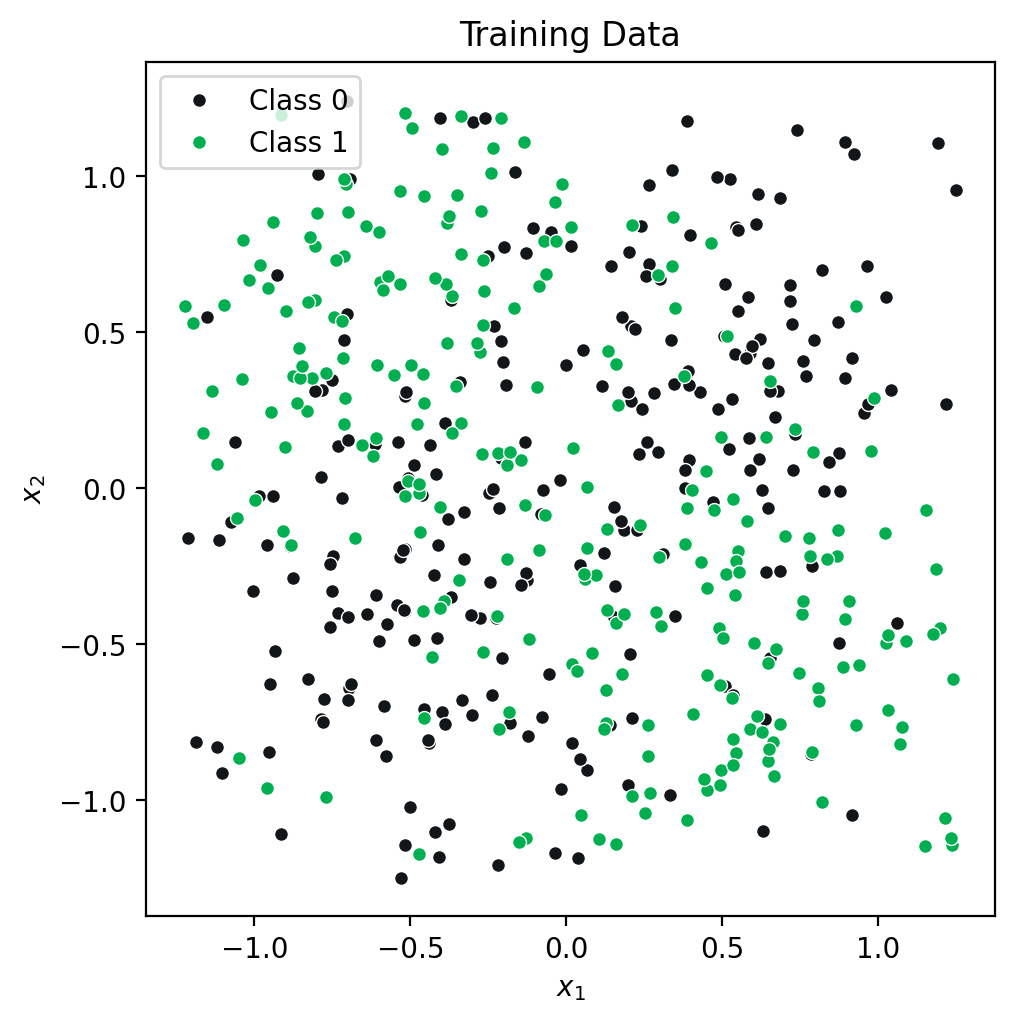

In [4]:
# Code to plot the sample data
def plot_data(ax, X, y, title, limits):
    # Select the colors to use in the plots
    color0 = "#121619"  # Dark grey
    color1 = "#00B050"  # Green
    color_boundary = "#858585"

    # Separate samples by class
    samples0 = X[y == 0]
    samples1 = X[y == 1]

    ax.plot(
        samples0[:, 0],
        samples0[:, 1],
        marker="o",
        markersize=5,
        linestyle="None",
        color=color0,
        markeredgecolor="w",
        markeredgewidth=0.5,
        label="Class 0",
    )
    ax.plot(
        samples1[:, 0],
        samples1[:, 1],
        marker="o",
        markersize=5,
        linestyle="None",
        color=color1,
        markeredgecolor="w",
        markeredgewidth=0.5,
        label="Class 1",
    )
    ax.set_title(title)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.legend(loc="upper left")
    ax.set_aspect("equal")


fig, ax = plt.subplots(constrained_layout=True, figsize=(5, 5))
limits = [-1.25, 1.25, -1.25, 1.25]
plot_data(ax, X_train, y_train, "Training Data", limits)

In [5]:
X_train.shape

(500, 2)


-   `learning_rate_init` = 0.03
-   `hidden_layer_sizes` = (30,30) (two hidden layers, each with 30
    nodes)
-   `alpha` = 0 (regularization penalty)
-   `solver` = ‘sgd’ (stochastic gradient descent optimizer)
-   `tol` = 1e-5 (this sets the convergence tolerance)
-   `early_stopping` = False (this prevents early stopping)
-   `activation` = ‘relu’ (rectified linear unit)
-   `n_iter_no_change` = 1000 (this prevents early stopping)
-   `batch_size` = 50 (size of the minibatch for stochastic gradient
    descent)
-   `max_iter` = 500 (maximum number of epochs, which is how many times
    each data point will be used, not the number of gradient steps)

<div style="page-break-before: always;"></div>

## 1.1 ##

In [6]:
learning_rate_init = 0.03
hidden_layer_sizes = (30, 30)
alpha = 0
solver = "sgd"
tol = 1e-5
early_stopping = False
activation = "relu"
n_iter_no_change = 1000
batch_size = 50
max_iter = 500

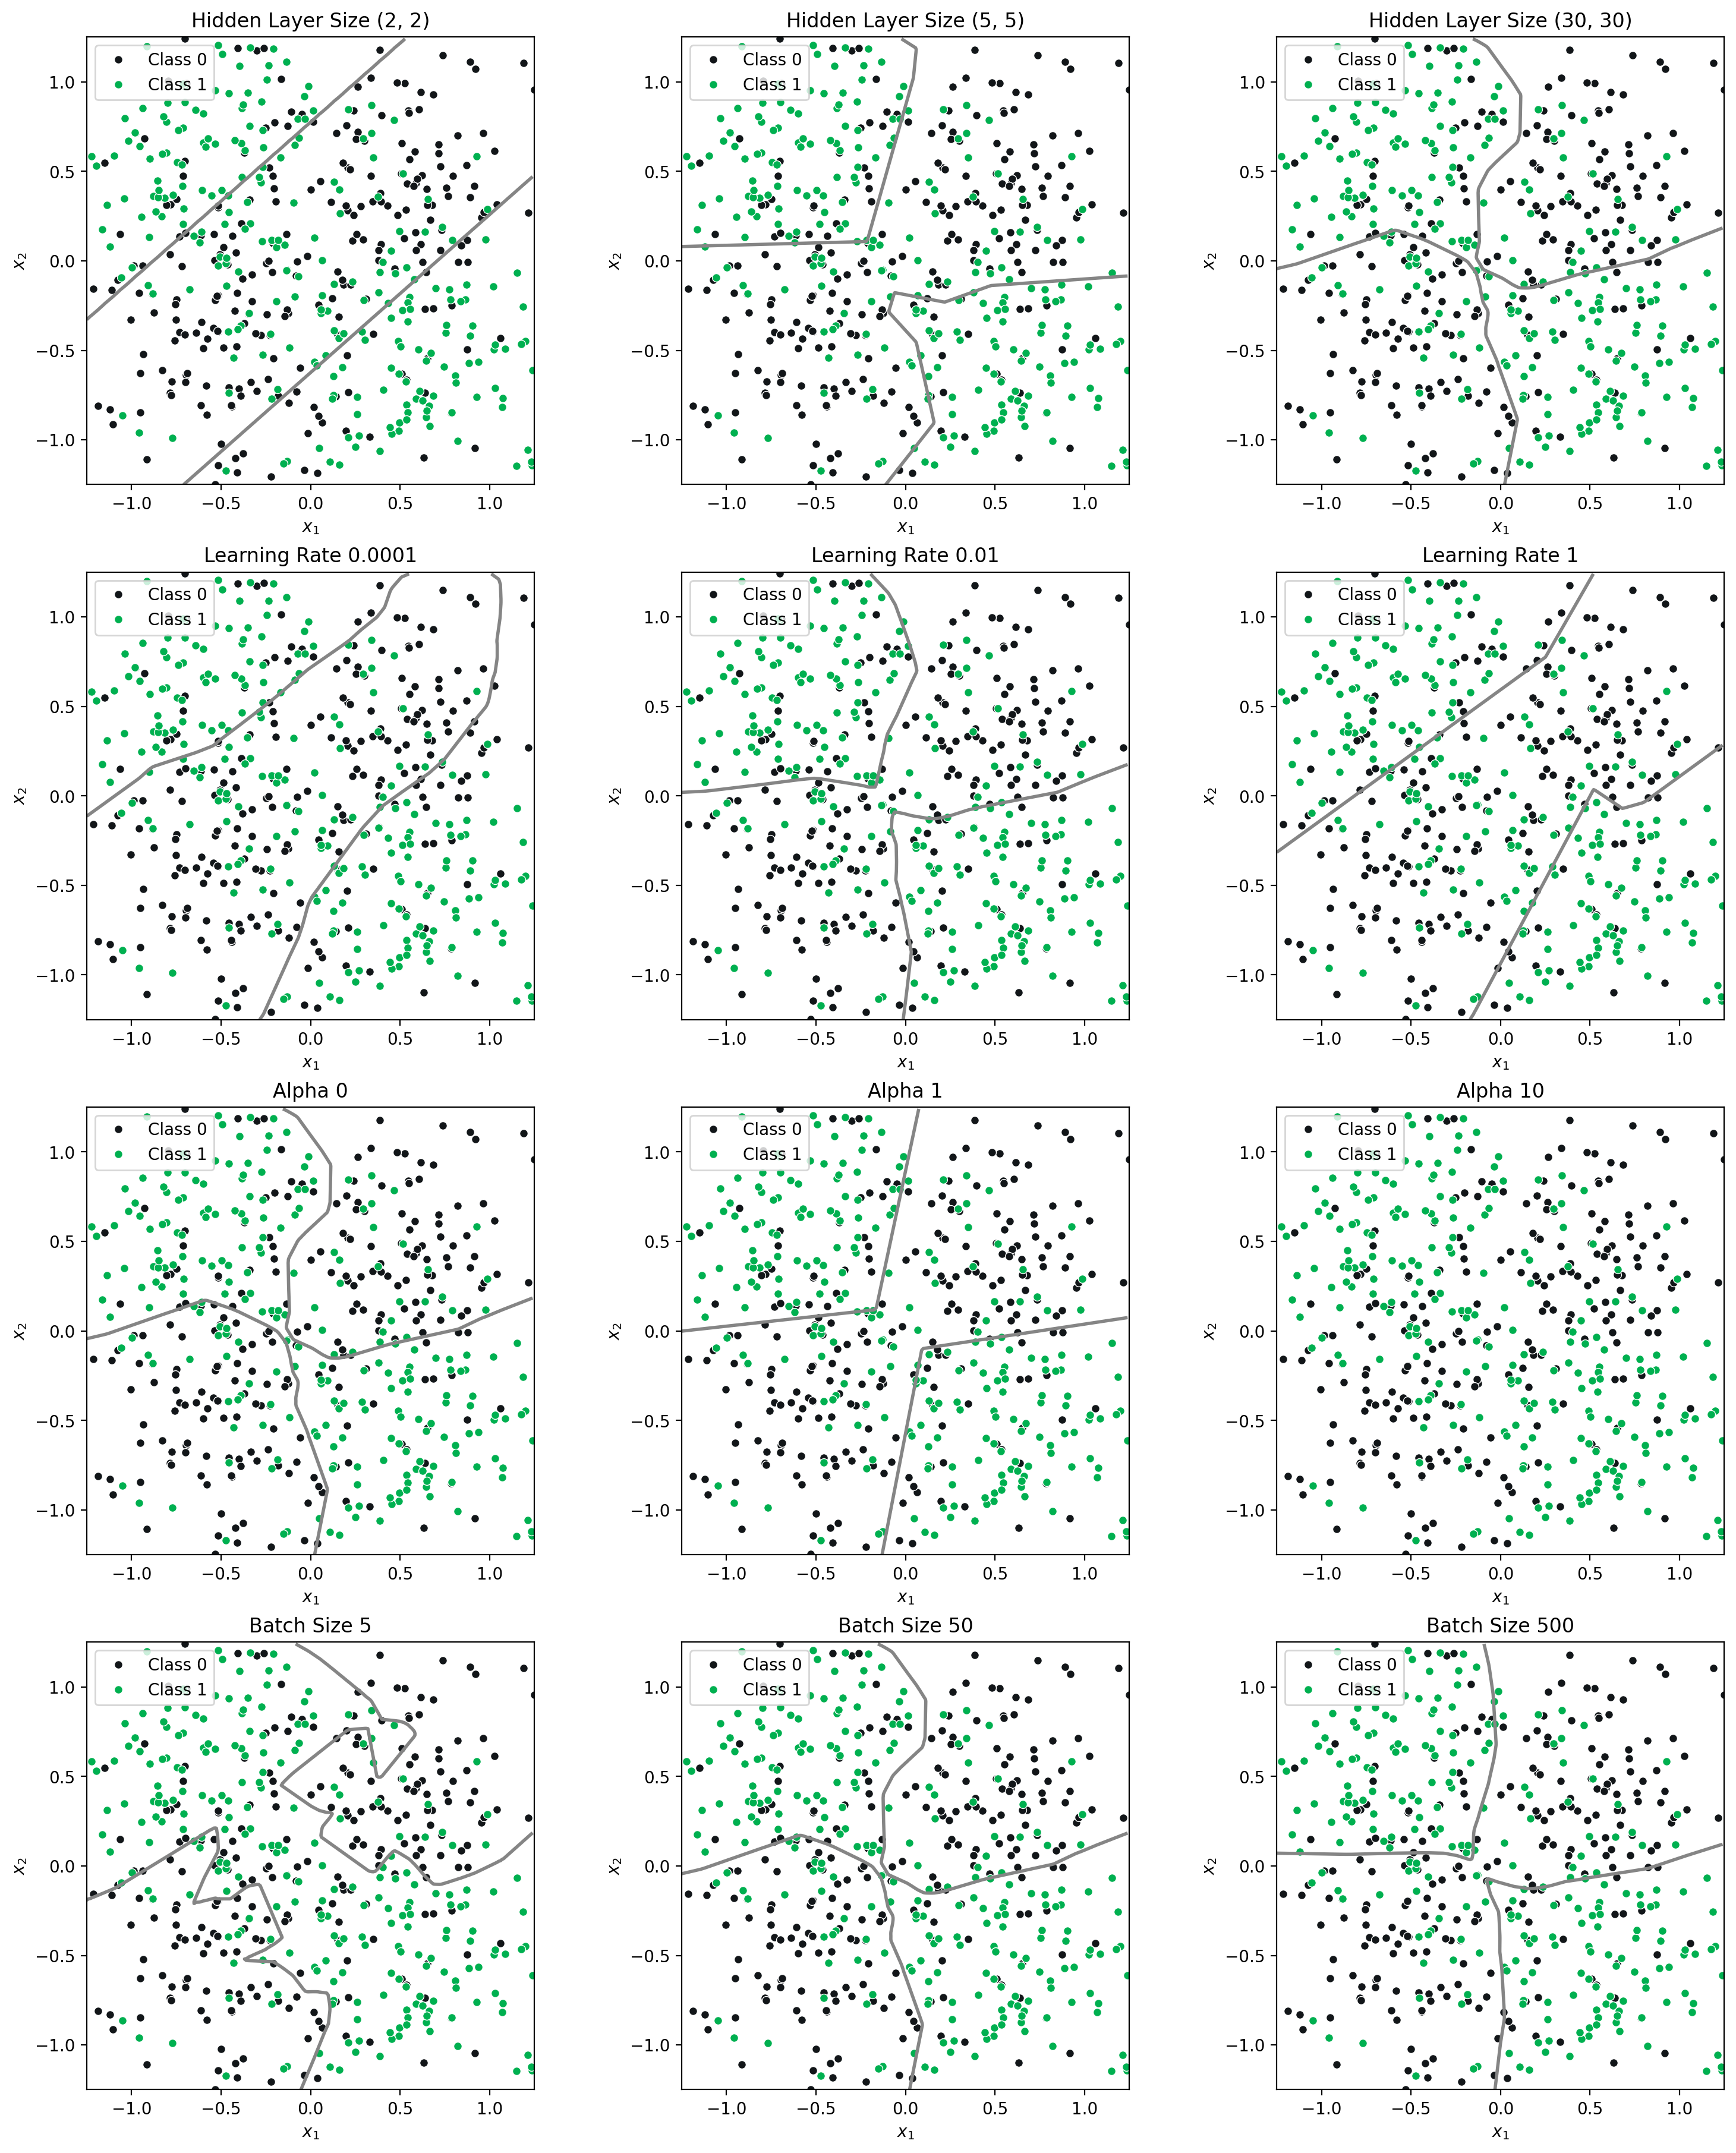

In [7]:
def plot_decision_boundary(ax, clf, limits, grid_step=0.01):
    x_min, x_max, y_min, y_max = limits
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, grid_step),
        np.arange(y_min, y_max, grid_step),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = clf.predict_proba(grid)[:, 1]
    Z = Z.reshape(xx.shape)
    ax.contour(xx, yy, Z, levels=[0.5], colors=["#858585"], linewidths=2)


limits = [-1.25, 1.25, -1.25, 1.25]

fig, ax = plt.subplots(4, 3, figsize=(15, 18), constrained_layout=True)


# for each hyperparameter, fix the other params as default and vary the hyperparam fitting a model with that change
# Part 1: Vary hidden layer size
hidden_layer_size_vals = [(2, 2), (5, 5), (30, 30)]
for j, size in enumerate(hidden_layer_size_vals):
    mlp = MLPClassifier(
        hidden_layer_sizes=size,
        learning_rate_init=learning_rate_init,
        alpha=alpha,
        solver=solver,
        tol=tol,
        early_stopping=early_stopping,
        activation=activation,
        n_iter_no_change=n_iter_no_change,
        batch_size=batch_size,
        max_iter=max_iter,
        random_state=0,
    )
    mlp.fit(X_train, y_train)

    plot_data(ax[0, j], X_train, y_train, f"Hidden Layer Size {size}", limits)
    plot_decision_boundary(ax[0, j], mlp, limits)
    ax[0, j].set_xlim(limits[0], limits[1])
    ax[0, j].set_ylim(limits[2], limits[3])

# Part 2: Vary learning rate
learning_rates = [0.0001, 0.01, 1]
for j, lr in enumerate(learning_rates):
    mlp = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        learning_rate_init=lr,
        alpha=alpha,
        solver=solver,
        tol=tol,
        early_stopping=early_stopping,
        activation=activation,
        n_iter_no_change=n_iter_no_change,
        batch_size=batch_size,
        max_iter=max_iter,
        random_state=0,
    )
    mlp.fit(X_train, y_train)

    plot_data(ax[1, j], X_train, y_train, f"Learning Rate {lr}", limits)
    plot_decision_boundary(ax[1, j], mlp, limits)
    ax[1, j].set_xlim(limits[0], limits[1])
    ax[1, j].set_ylim(limits[2], limits[3])

# Part 3: Vary regularization
regularization_vals = [0, 1, 10]
for j, reg_val in enumerate(regularization_vals):
    mlp = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        learning_rate_init=learning_rate_init,
        alpha=reg_val,
        solver=solver,
        tol=tol,
        early_stopping=early_stopping,
        activation=activation,
        n_iter_no_change=n_iter_no_change,
        batch_size=batch_size,
        max_iter=max_iter,
        random_state=0,
    )
    mlp.fit(X_train, y_train)

    plot_data(ax[2, j], X_train, y_train, f"Alpha {reg_val}", limits)
    plot_decision_boundary(ax[2, j], mlp, limits)
    ax[2, j].set_xlim(limits[0], limits[1])
    ax[2, j].set_ylim(limits[2], limits[3])

# Part 4: Vary batch size
batch_sizes = [5, 50, 500]
for j, bs in enumerate(batch_sizes):
    mlp = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        learning_rate_init=learning_rate_init,
        alpha=alpha,
        solver=solver,
        tol=tol,
        early_stopping=early_stopping,
        activation=activation,
        n_iter_no_change=n_iter_no_change,
        batch_size=bs,
        max_iter=max_iter,
        random_state=0,
    )
    mlp.fit(X_train, y_train)

    plot_data(ax[3, j], X_train, y_train, f"Batch Size {bs}", limits)
    plot_decision_boundary(ax[3, j], mlp, limits)
    ax[3, j].set_xlim(limits[0], limits[1])
    ax[3, j].set_ylim(limits[2], limits[3])

plt.show()

# <div style="page-break-before: always;"></div>

## 1.2 ##

(averaged over 5 runs each)
Optimal Learning Rate: 0.004281332398719391  mean= 0.7348000000000001  std= 0.003249615361854387
Optimal Regularization Alpha: 1e-08  mean= 0.732  std= 0.004381780460041332
Optimal Batch Size: 250  mean= 0.7344  std= 0.004963869458396347


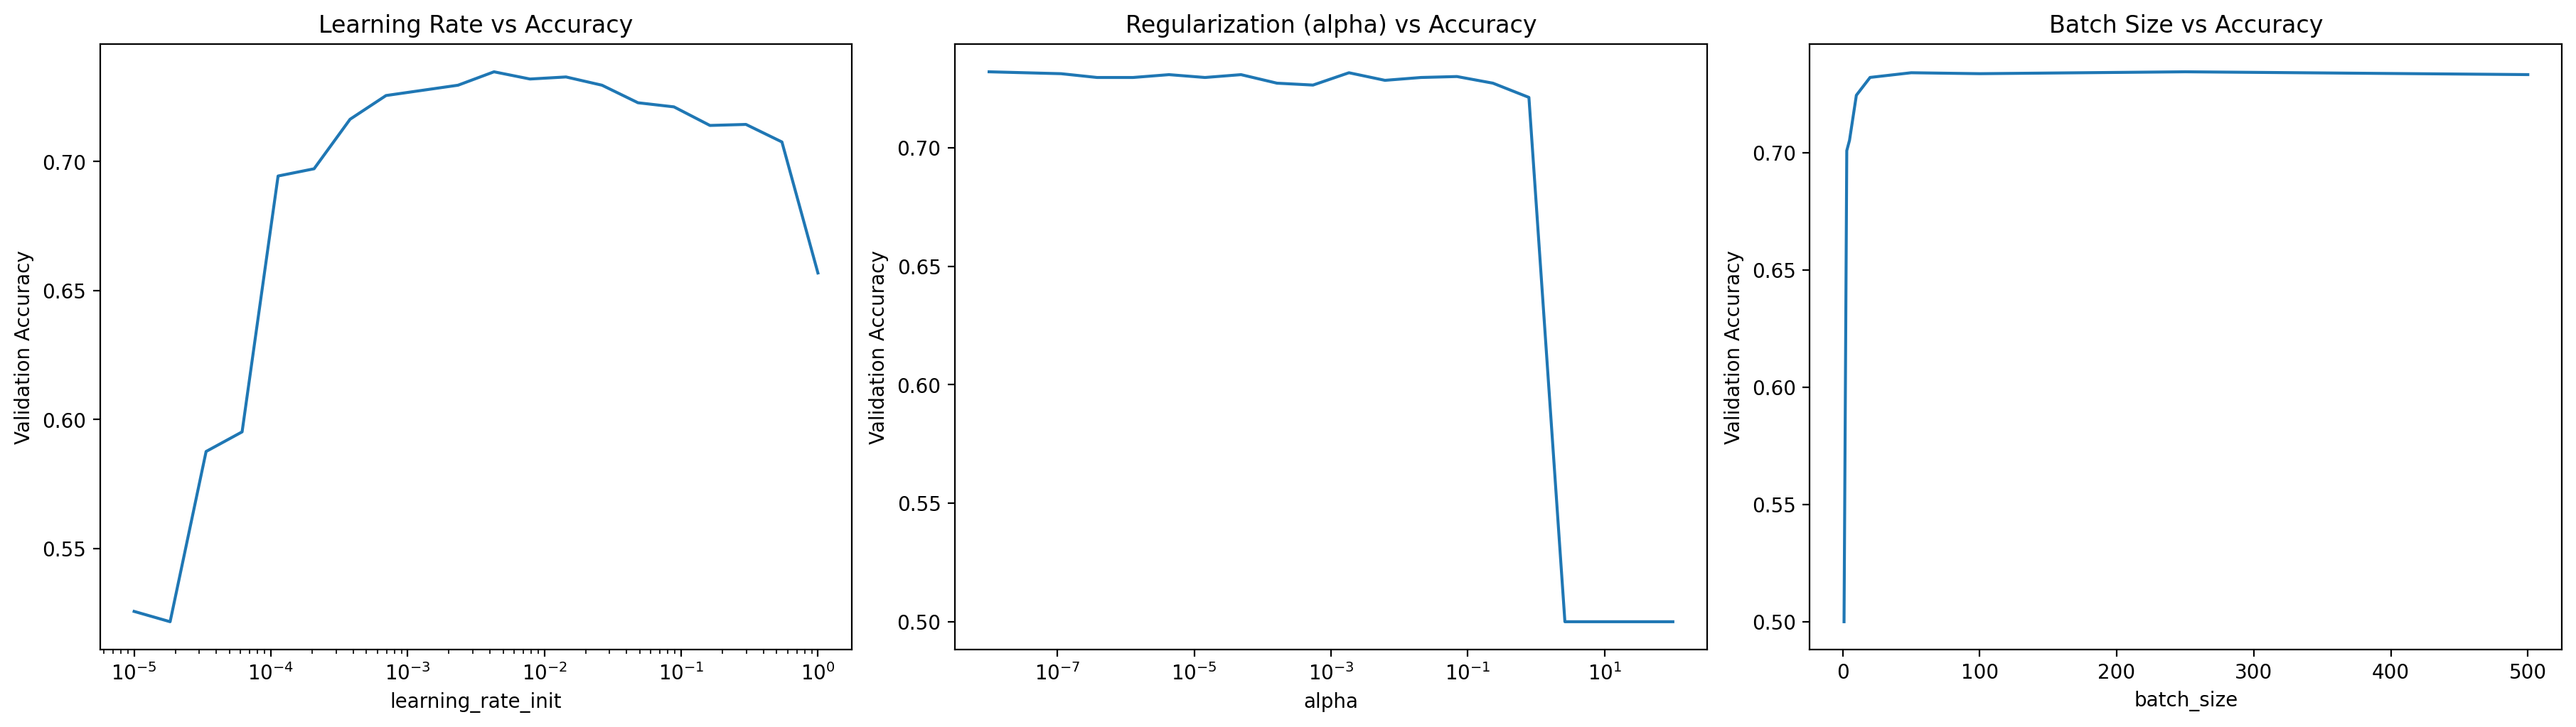

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier


# create a function to run the model multiple times with noise to find optimal hyperparameter vals
# store average of score to find best hyperparam
def run_test(n_repeats=10, make_plots=True):
    learning_rates = np.logspace(-5, 0, num=20)

    lr_means, lr_stds = [], []

    for val in learning_rates:
        scores = []
        for _ in range(n_repeats):
            mlp = MLPClassifier(
                hidden_layer_sizes=hidden_layer_sizes,
                learning_rate_init=val,
                alpha=alpha,
                solver=solver,
                tol=tol,
                early_stopping=early_stopping,
                activation=activation,
                n_iter_no_change=n_iter_no_change,
                batch_size=batch_size,
                max_iter=max_iter,
            )
            mlp.fit(X_train, y_train)
            scores.append(mlp.score(X_val, y_val))

        lr_means.append(np.mean(scores))
        lr_stds.append(np.std(scores))

    regularization_values = np.logspace(-8, 2, num=20)
    reg_means, reg_stds = [], []

    for val in regularization_values:
        scores = []
        for _ in range(n_repeats):
            mlp = MLPClassifier(
                hidden_layer_sizes=hidden_layer_sizes,
                learning_rate_init=learning_rate_init,
                alpha=val,
                solver=solver,
                tol=tol,
                early_stopping=early_stopping,
                activation=activation,
                n_iter_no_change=n_iter_no_change,
                batch_size=batch_size,
                max_iter=max_iter,
            )
            mlp.fit(X_train, y_train)
            scores.append(mlp.score(X_val, y_val))

        reg_means.append(np.mean(scores))
        reg_stds.append(np.std(scores))

    batch_size_values = [1, 3, 5, 10, 20, 50, 100, 250, 500]
    batch_means, batch_stds = [], []

    for val in batch_size_values:
        scores = []
        for _ in range(n_repeats):
            mlp = MLPClassifier(
                hidden_layer_sizes=hidden_layer_sizes,
                learning_rate_init=learning_rate_init,
                alpha=alpha,
                solver=solver,
                tol=tol,
                early_stopping=early_stopping,
                activation=activation,
                n_iter_no_change=n_iter_no_change,
                batch_size=val,
                max_iter=max_iter,
            )
            mlp.fit(X_train, y_train)
            scores.append(mlp.score(X_val, y_val))

        batch_means.append(np.mean(scores))
        batch_stds.append(np.std(scores))

    optimal_lr = learning_rates[int(np.argmax(lr_means))]
    optimal_alpha = regularization_values[int(np.argmax(reg_means))]
    optimal_batch_size = batch_size_values[int(np.argmax(batch_means))]

    print(f"(averaged over {n_repeats} runs each)")
    print(
        "Optimal Learning Rate:",
        optimal_lr,
        " mean=",
        lr_means[int(np.argmax(lr_means))],
        " std=",
        lr_stds[int(np.argmax(lr_means))],
    )
    print(
        "Optimal Regularization Alpha:",
        optimal_alpha,
        " mean=",
        reg_means[int(np.argmax(reg_means))],
        " std=",
        reg_stds[int(np.argmax(reg_means))],
    )
    print(
        "Optimal Batch Size:",
        optimal_batch_size,
        " mean=",
        batch_means[int(np.argmax(batch_means))],
        " std=",
        batch_stds[int(np.argmax(batch_means))],
    )

    if make_plots:
        fig, ax = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

        ax[0].plot(learning_rates, lr_means)
        ax[0].set_xscale("log")
        ax[0].set_title("Learning Rate vs Accuracy")
        ax[0].set_xlabel("learning_rate_init")
        ax[0].set_ylabel("Validation Accuracy")

        ax[1].plot(regularization_values, reg_means)
        ax[1].set_xscale("log")
        ax[1].set_title("Regularization (alpha) vs Accuracy")
        ax[1].set_xlabel("alpha")
        ax[1].set_ylabel("Validation Accuracy")

        ax[2].plot(batch_size_values, batch_means)
        ax[2].set_title("Batch Size vs Accuracy")
        ax[2].set_xlabel("batch_size")
        ax[2].set_ylabel("Validation Accuracy")

        plt.show()

    return optimal_lr, optimal_alpha, optimal_batch_size


optimal_lr, optimal_alpha, optimal_batch_size = run_test(n_repeats=5, make_plots=True)

**From manually testing the hyperparameters to produce the plots above and by looking at the average accuracy scores of each hyperparameter value tested (due to noise simulate 5 times and look at average) to see the value with the highest average score (both by inspection of plots and with code above), the most optimal choices are as follows.**

**Using a learning rate of 0.004, a regularization alpha of 1e-8 and optimal batch size of 250. These hyperparameters mean the model updates its weights in moderately sized steps, applies light penalty to prevent overfitting, and processes 250 training samples at a time before each weight update.**

# <div style="page-break-before: always;"></div>

## 1.3 ##

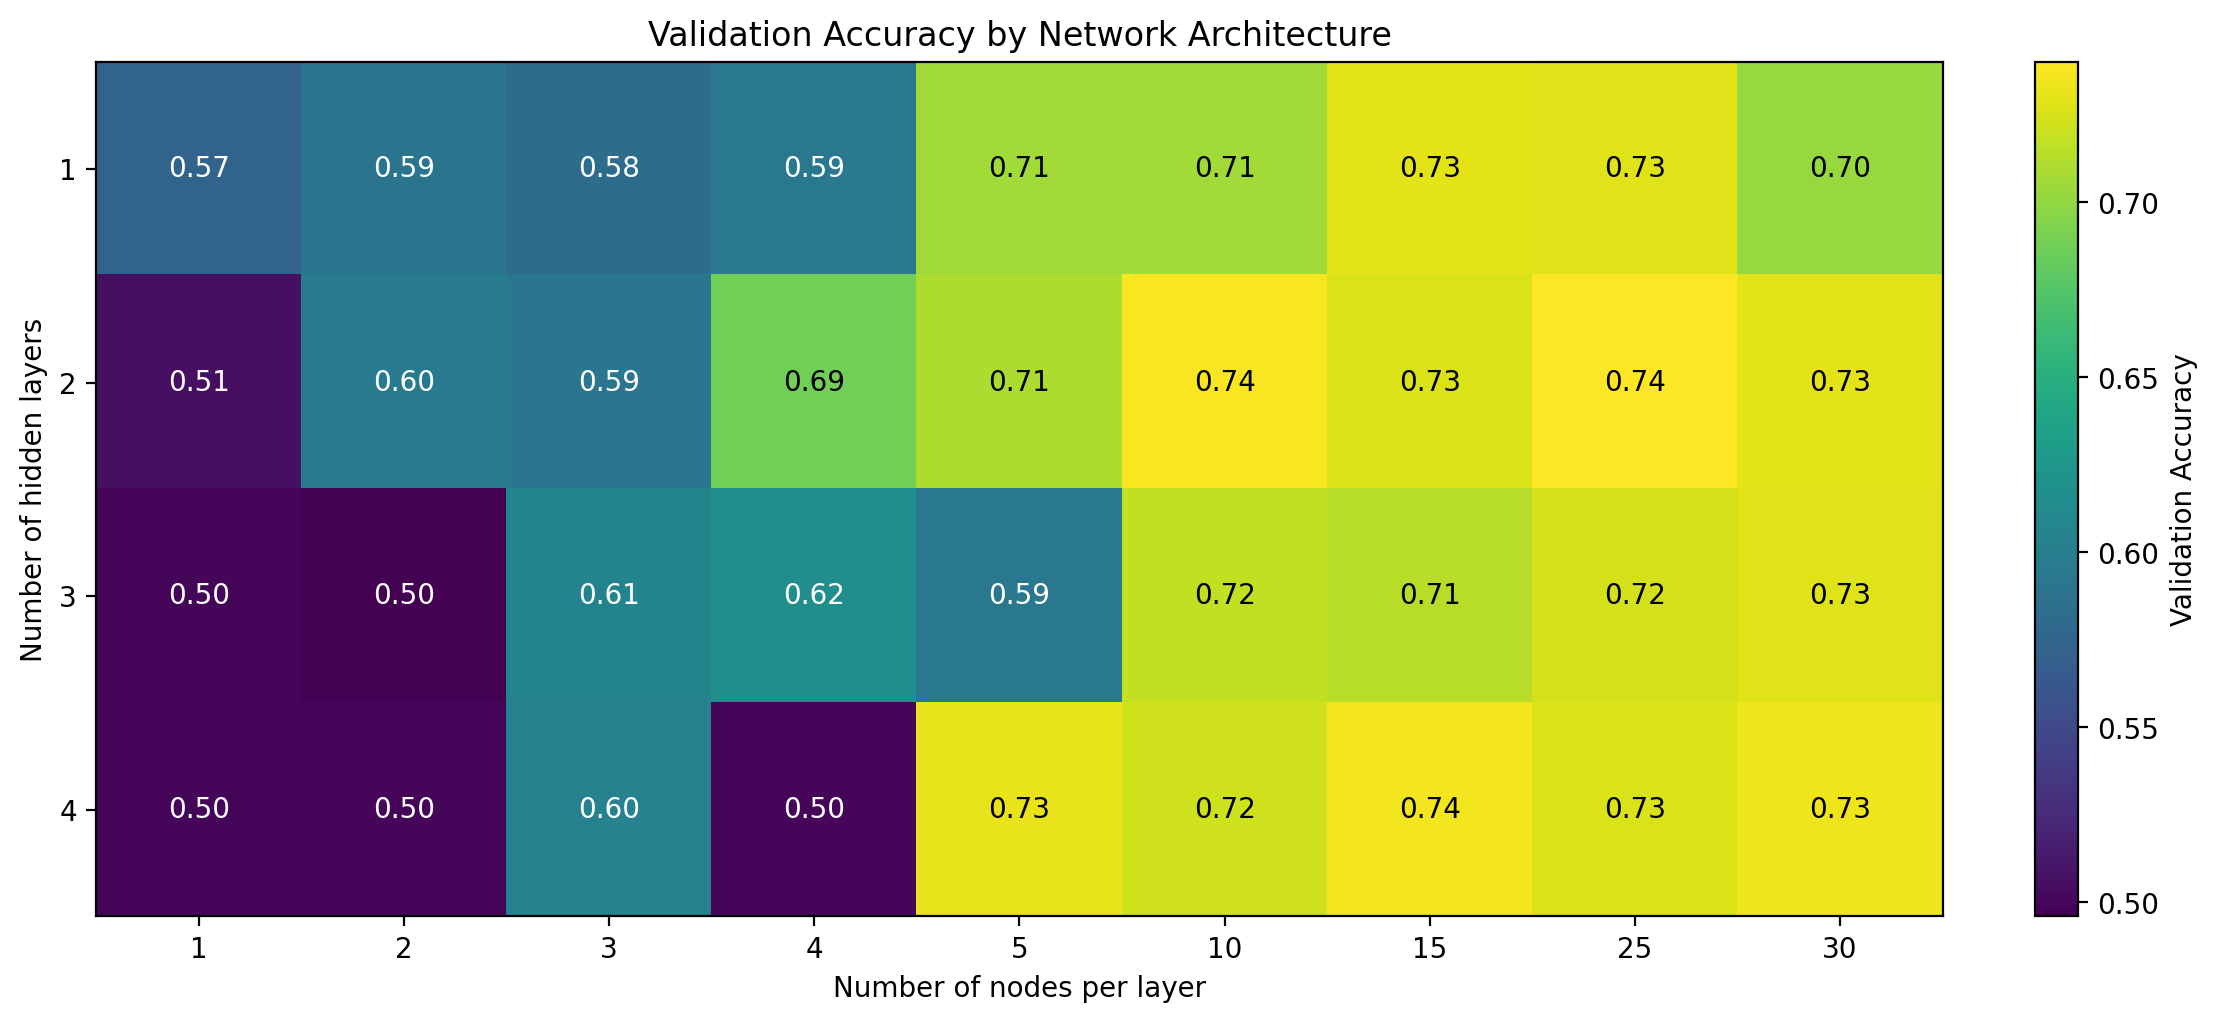

Best validation accuracy: 0.74
Selected architecture: (25, 25)
Number of weights (tie-break): 751


In [9]:
nodes_vals = [1, 2, 3, 4, 5, 10, 15, 25, 30]
num_layers = [1, 2, 3, 4]

# store validation accuracies: rows=layers, cols=nodes
acc_grid = np.zeros((len(num_layers), len(nodes_vals)))

#  train MLP and get accuracy for every combination
for i, L in enumerate(num_layers):
    for j, n in enumerate(nodes_vals):
        layer = (n,) * L

        mlp = MLPClassifier(
            hidden_layer_sizes=layer,
            learning_rate_init=optimal_lr,
            alpha=optimal_alpha,
            solver=solver,
            tol=tol,
            early_stopping=early_stopping,
            activation=activation,
            n_iter_no_change=n_iter_no_change,
            batch_size=optimal_batch_size,
            max_iter=max_iter,
        )
        mlp.fit(X_train, y_train)

        acc_grid[i, j] = mlp.score(X_val, y_val)


fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
im = ax.imshow(acc_grid, aspect="auto")
ax.set_xticks(np.arange(len(nodes_vals)))
ax.set_yticks(np.arange(len(num_layers)))
ax.set_xticklabels(nodes_vals)
ax.set_yticklabels(num_layers)

ax.set_xlabel("Number of nodes per layer")
ax.set_ylabel("Number of hidden layers")
ax.set_title("Validation Accuracy by Network Architecture")

plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
for i in range(acc_grid.shape[0]):
    for j in range(acc_grid.shape[1]):
        ax.text(
            j,
            i,
            f"{acc_grid[i, j]:.2f}",
            ha="center",
            va="center",
            color=(
                "white"
                if acc_grid[i, j] < (acc_grid.min() + acc_grid.max()) / 2
                else "black"
            ),
        )

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Validation Accuracy")

plt.show()


def num_weights(input_dim, n, L):
    total = (input_dim + 1) * n  # input -> first hidden (+bias)
    total += (L - 1) * (n + 1) * n  # hidden -> hidden layers (+bias)
    total += (n + 1) * 1  # last hidden -> output (+bias)
    return total


input_dim = X_train.shape[1]
best_acc = acc_grid.max()

tol_acc = 1e-12
cands = []
for i, L in enumerate(num_layers):
    for j, n in enumerate(nodes_vals):
        if abs(acc_grid[i, j] - best_acc) <= tol_acc:
            cands.append((L, n, num_weights(input_dim, n, L)))

best_L, best_n, best_w = sorted(cands, key=lambda t: t[2])[0]

print("Best validation accuracy:", round(best_acc, 4))
print("Selected architecture:", (best_n,) * best_L)
print("Number of weights (tie-break):", best_w)

**The best validation accuracy was about 0.74 and several larger architectures performed with similar accuracies. I selected a 2-layer network with 10 nodes per layer, (10, 10), because it had the highest accuracy while using fewer total weights and was more simple than the deeper/wider networks ((25, 25) which performed the same) with similar validation accuracy, so it was the simplest model among the top performers.**

# <div style="page-break-before: always;"></div>

## 1.4 ##

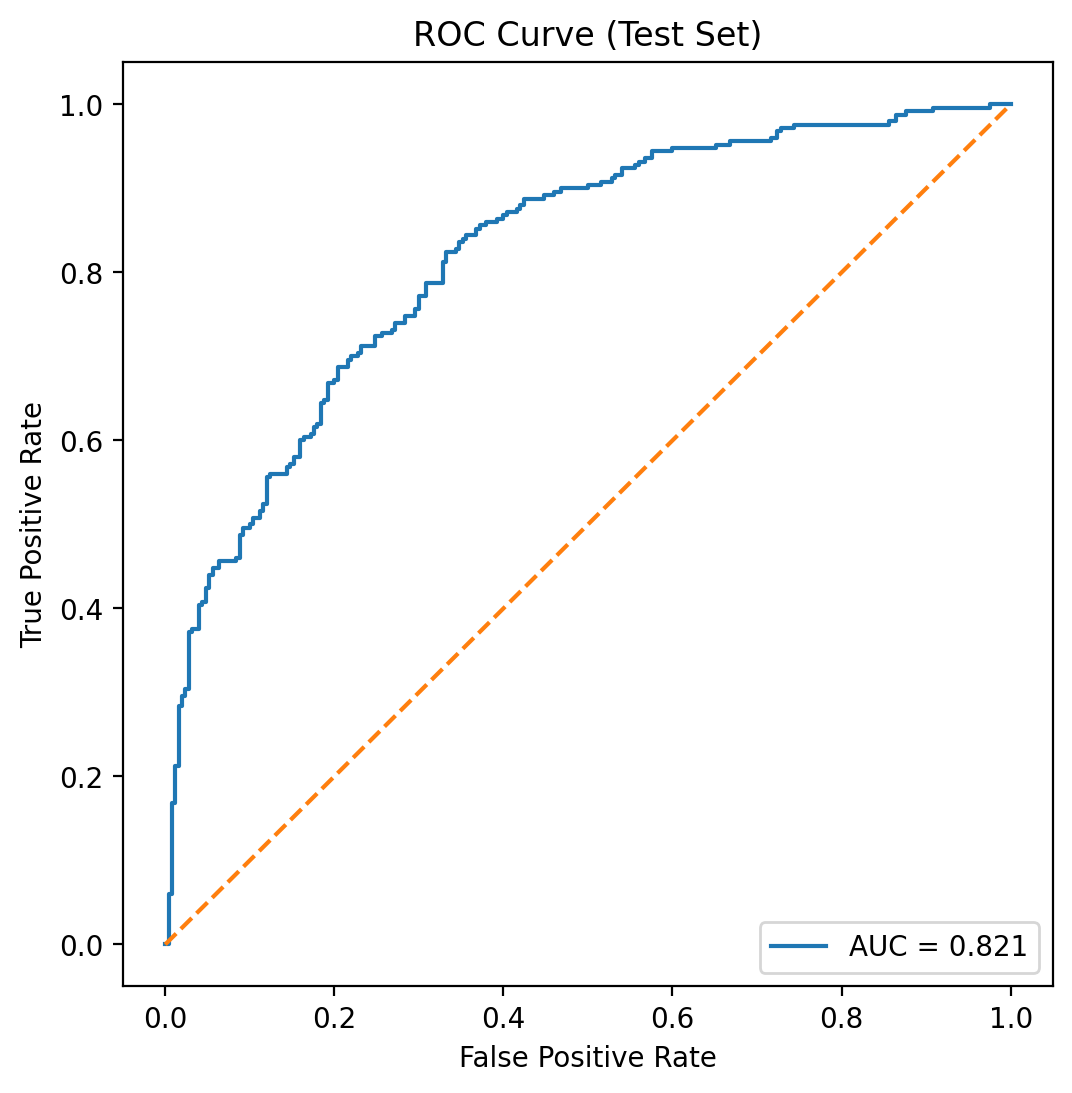

In [10]:
best_hidden = (best_n,) * best_L
greedy_best_mlp = MLPClassifier(
    hidden_layer_sizes=best_hidden,
    learning_rate_init=optimal_lr,
    alpha=optimal_alpha,
    solver=solver,
    tol=tol,
    early_stopping=early_stopping,
    activation=activation,
    n_iter_no_change=n_iter_no_change,
    batch_size=optimal_batch_size,
    max_iter=max_iter,
)
greedy_best_mlp.fit(X_train_plus_val, y_train_plus_val)

final_accuracy = mlp.score(X_test, y_test)
# TODO:  plot ROC Curve

from sklearn.metrics import roc_curve, auc

# get predicted probabilities for positive class
y_prob = greedy_best_mlp.predict_proba(X_test)[:, 1]

# compute ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# plot
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.legend(loc="lower right")
plt.show()

# <div style="page-break-before: always;"></div>

## 1.5 ##

Random search best params: {'alpha': np.float64(1.5362220489793648), 'batch_size': 500, 'hidden_layer_sizes': (30, 30), 'learning_rate_init': np.float64(0.9569828691089484)}
Random search best val accuracy: 0.748
Greedy test accuracy: 0.734
Random search test accuracy: 0.736


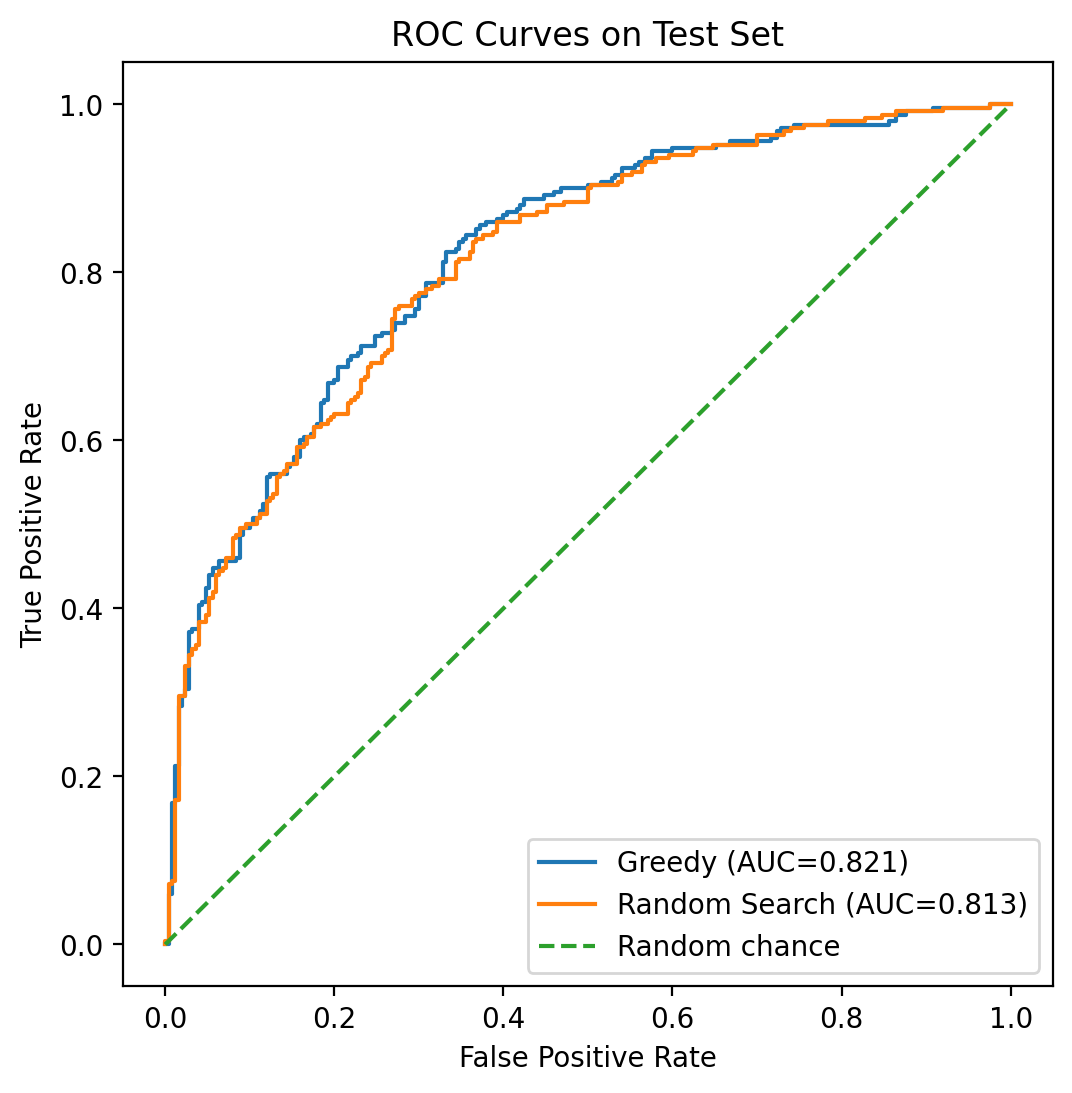

Greedy AUC: 0.8208799999999999
Random Search AUC: 0.813472


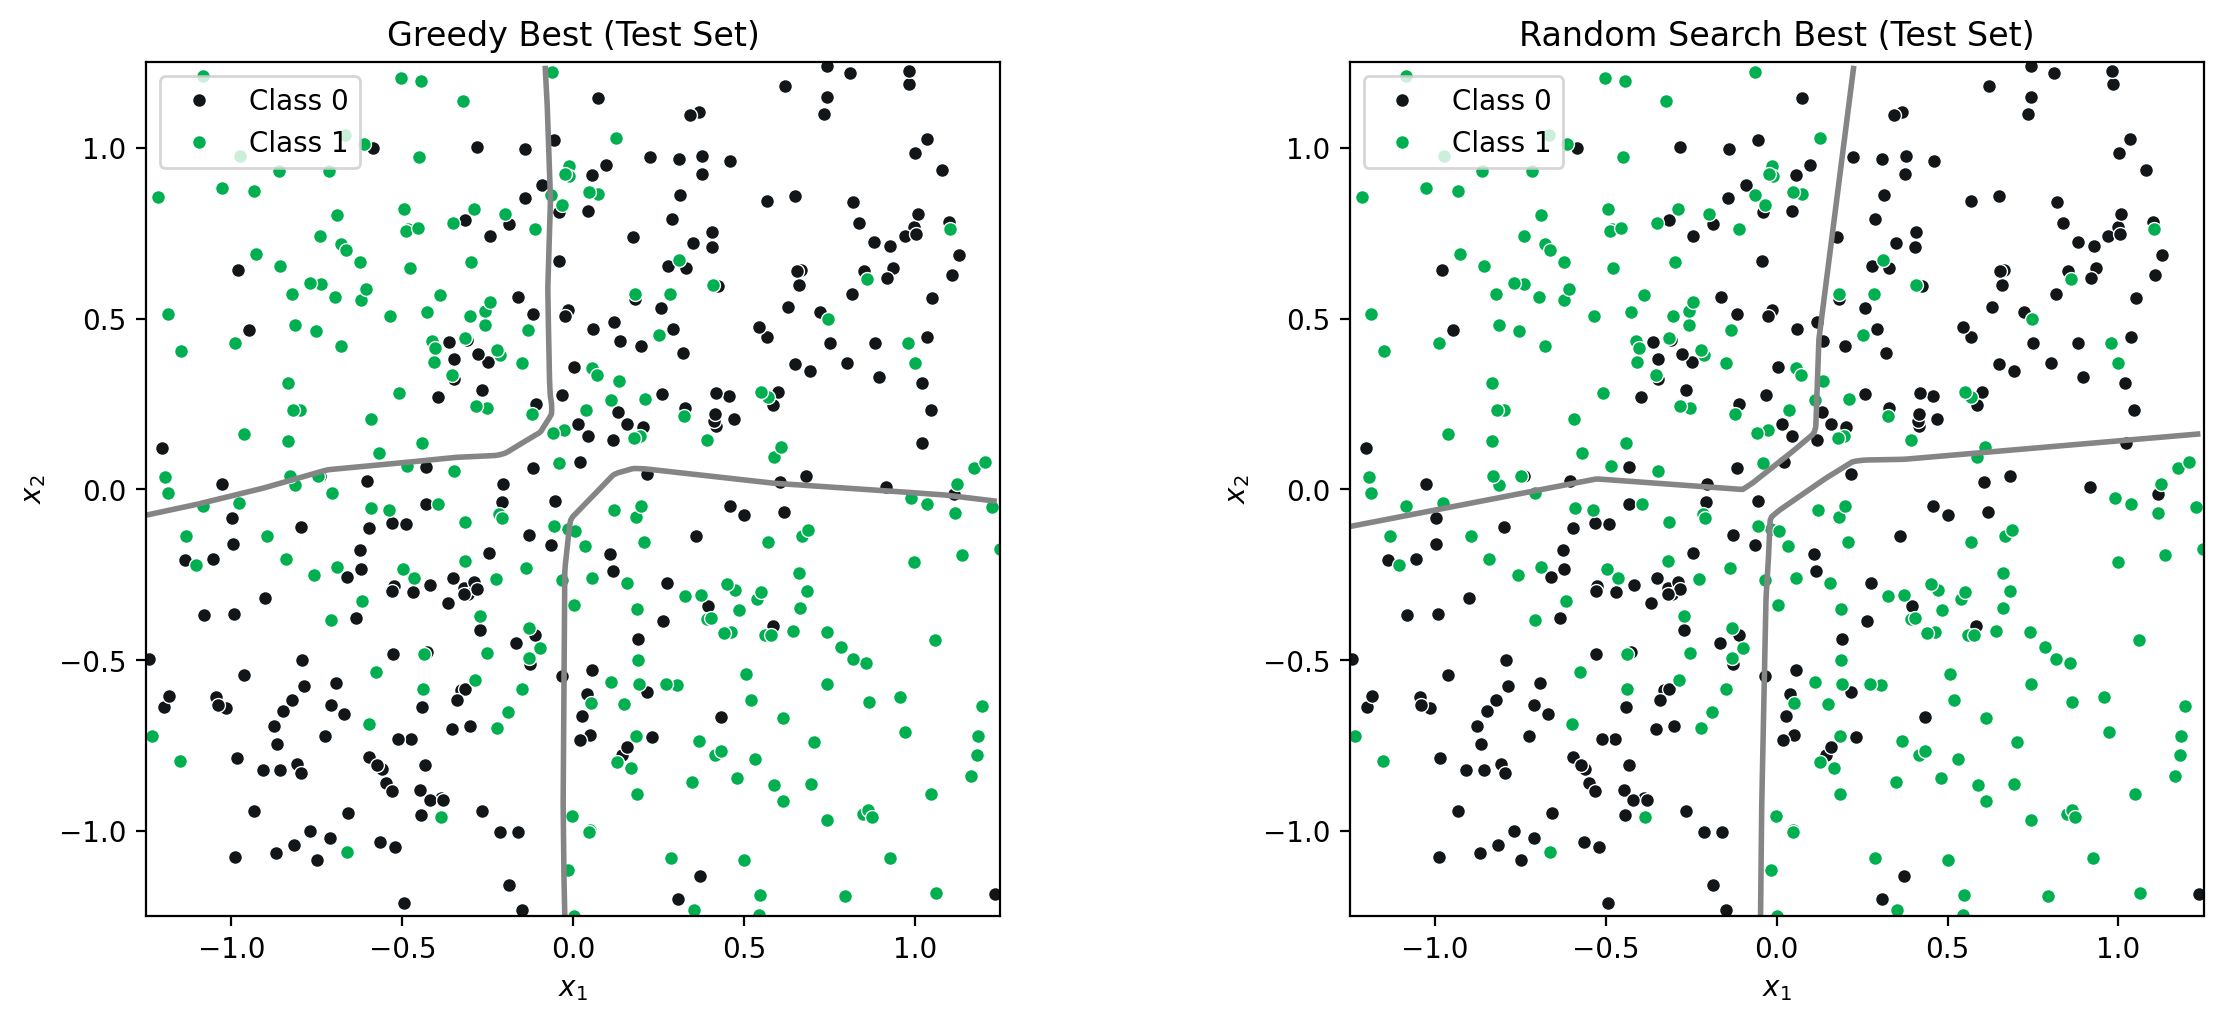

In [11]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, auc
from scipy.stats import loguniform

n_iter_search = 200

learning_rates_dist = loguniform(1e-5, 1e0)
alpha_dist = loguniform(1e-8, 1e2)
batch_size_values = [1, 3, 5, 10, 20, 50, 100, 250, 500]

nodes_vals = [1, 2, 3, 4, 5, 10, 15, 25, 30]
num_layers = [1, 2, 3, 4]
hidden_layer_combinations = [(n,) * L for L in num_layers for n in nodes_vals]

param_dist = {
    "hidden_layer_sizes": hidden_layer_combinations,
    "learning_rate_init": learning_rates_dist,
    "alpha": alpha_dist,
    "batch_size": batch_size_values,
}

mlp = MLPClassifier(
    hidden_layer_sizes=hidden_layer_sizes,
    learning_rate_init=learning_rate_init,
    alpha=alpha,
    solver=solver,
    tol=tol,
    early_stopping=early_stopping,
    activation=activation,
    n_iter_no_change=n_iter_no_change,
    batch_size=batch_size,
    max_iter=max_iter,
)

random_search = RandomizedSearchCV(
    estimator=mlp,
    param_distributions=param_dist,
    n_iter=n_iter_search,
    scoring="accuracy",
    cv=train_val_split,
    refit=True,
    n_jobs=-1,
)

random_search.fit(X_train_plus_val, y_train_plus_val)

print("Random search best params:", random_search.best_params_)
print("Random search best val accuracy:", random_search.best_score_)

random_best_mlp = random_search.best_estimator_

greedy_test_acc = greedy_best_mlp.score(X_test, y_test)
random_test_acc = random_best_mlp.score(X_test, y_test)

print("Greedy test accuracy:", greedy_test_acc)
print("Random search test accuracy:", random_test_acc)

y_prob_greedy = greedy_best_mlp.predict_proba(X_test)[:, 1]
y_prob_random = random_best_mlp.predict_proba(X_test)[:, 1]

fpr_g, tpr_g, _ = roc_curve(y_test, y_prob_greedy)
fpr_r, tpr_r, _ = roc_curve(y_test, y_prob_random)

auc_g = auc(fpr_g, tpr_g)
auc_r = auc(fpr_r, tpr_r)

plt.figure(figsize=(6, 6))
plt.plot(fpr_g, tpr_g, label=f"Greedy (AUC={auc_g:.3f})")
plt.plot(fpr_r, tpr_r, label=f"Random Search (AUC={auc_r:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves on Test Set")
plt.legend(loc="lower right")
plt.show()

print("Greedy AUC:", auc_g)
print("Random Search AUC:", auc_r)

limits = [-1.25, 1.25, -1.25, 1.25]

fig, ax = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

plot_data(ax[0], X_test, y_test, "Greedy Best (Test Set)", limits)
plot_decision_boundary(ax[0], greedy_best_mlp, limits)

plot_data(ax[1], X_test, y_test, "Random Search Best (Test Set)", limits)
plot_decision_boundary(ax[1], random_best_mlp, limits)

for a in ax:
    a.set_xlim(limits[0], limits[1])
    a.set_ylim(limits[2], limits[3])

plt.show()



The greedy algorithm had a slighly higher AUC than the random search (0.822 compared to 0.818). The ROC curves show that the greedy and random search algorithms are very similar in their results, both nearly overlapping and performing much better than random chance. The results were very similar as shown below: 


Random search best params:

 {'alpha': np.float64(0.05427951777606573), 'batch_size': 20, 'hidden_layer_sizes': (25, 25), 'learning_rate_init': np.float64(7.418683423365595e-05)}

Random search best val accuracy: 0.75

Greedy test accuracy: 0.728

Random search test accuracy: 0.724

# <div style="page-break-before: always;"></div>

<div style="page-break-before: always;"></div>

# Exercise 2 #


## 2.1 ##

In [2]:
# neural network class skeleton code


class myNeuralNetwork(object):

    def __init__(self, n_in, n_layer1, n_layer2, n_out, learning_rate=0.01):
        """__init__
        Class constructor: Initialize the parameters of the network including
        the learning rate, layer sizes, and each of the parameters
        of the model (weights, placeholders for activations, inputs,
        deltas for gradients, and weight gradients). This method
        should also initialize the weights of your model randomly
            Input:
                n_in:          number of inputs
                n_layer1:      number of nodes in layer 1
                n_layer2:      number of nodes in layer 2
                n_out:         number of output nodes
                learning_rate: learning rate for gradient descent
            Output:
                none
        """

        self.n_in = n_in
        self.n_layer1 = n_layer1
        self.n_layer2 = n_layer2
        self.n_out = n_out
        self.learning_rate = learning_rate

        rng = np.random.default_rng()

        # scikit learn uses xavier/glorot init for sigmoid nets
        def xavier(fan_in, fan_out):
            limit = np.sqrt(6.0 / (fan_in + fan_out))
            return rng.uniform(-limit, limit, size=(fan_in, fan_out))

        self.W1 = xavier(self.n_in, self.n_layer1)
        self.b1 = np.zeros((1, self.n_layer1))

        self.W2 = xavier(self.n_layer1, self.n_layer2)
        self.b2 = np.zeros((1, self.n_layer2))

        self.W3 = xavier(self.n_layer2, self.n_out)
        self.b3 = np.zeros((1, self.n_out))

        self.x = None
        self.z1 = None
        self.a1 = None
        self.z2 = None
        self.a2 = None
        self.z3 = None
        self.a3 = None

        self.dW1 = np.zeros_like(self.W1)
        self.db1 = np.zeros_like(self.b1)
        self.dW2 = np.zeros_like(self.W2)
        self.db2 = np.zeros_like(self.b2)
        self.dW3 = np.zeros_like(self.W3)
        self.db3 = np.zeros_like(self.b3)

    def forward_propagation(self, x):
        """forward_propagation
        Takes a vector of your input data (one sample) and feeds
        it forward through the neural network, calculating activations and
        layer node values along the way.
            Input:
                x: a vector of data representing 1 sample [n_in x 1]
            Output:
                y_hat: a vector (or scaler of predictions) [n_out x 1]
                (typically n_out will be 1 for binary classification)
        """
        if x.ndim == 1:
            x = x.reshape(1, -1)

        self.x = x

        self.z1 = self.x @ self.W1 + self.b1
        self.a1 = self.sigmoid(self.z1)

        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.sigmoid(self.z2)

        self.z3 = self.a2 @ self.W3 + self.b3
        self.a3 = self.sigmoid(self.z3)

        return self.a3

    def compute_loss(self, X, y):
        """compute_loss
        Computes the current loss/cost function of the neural network
        based on the weights and the data input into this function.
        To do so, it runs the X data through the network to generate
        predictions, then compares it to the target variable y using
        the cost/loss function
            Input:
                X: A matrix of N samples of data [N x n_in]
                y: Target variable [N x 1]
            Output:
                loss: a scalar measure of loss/cost
        """

        X = np.asarray(X)
        y = np.asarray(y).reshape(-1, 1)

        y_hat = self.predict_proba(X)
        # eps = 1e-12
        # y_hat = np.clip(y_hat, eps, 1 - eps)

        return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

    def backpropagate(self, x, y):
        """backpropagate
        Backpropagate the error from one sample determining the gradients
        with respect to each of the weights in the network. The steps for
        this algorithm are:
            1. Run a forward pass of the model to get the activations
               Corresponding to x and get the loss functionof the model
               predictions compared to the target variable y
            2. Compute the deltas (see lecture notes) and values of the
               gradient with respect to each weight in each layer moving
               backwards through the network

            Input:
                x: A vector of 1 samples of data [n_in x 1]
                y: Target variable [scalar]
            Output:
                loss: a scalar measure of th loss/cost associated with x,y
                      and the current model weights
        """
        # first forward poss
        y = float(y)
        y_hat = self.forward_propagation(x)

        # get loss
        eps = 1e-12
        yh = float(np.clip(y_hat[0, 0], eps, 1 - eps))
        loss = -(y * np.log(yh) + (1 - y) * np.log(1 - yh))

        # compute gradients
        delta3 = y_hat - y  # (1, n_out)

        self.dW3 = self.a2.T @ delta3
        self.db3 = delta3

        delta2 = (delta3 @ self.W3.T) * self.sigmoid_derivative(self.a2)
        self.dW2 = self.a1.T @ delta2
        self.db2 = delta2

        delta1 = (delta2 @ self.W2.T) * self.sigmoid_derivative(self.a1)
        self.dW1 = self.x.T @ delta1
        self.db1 = delta1

        return loss

    def stochastic_gradient_descent_step(self):
        """stochastic_gradient_descent_step [OPTIONAL - you may also do this
        directly in backpropagate]
        Using the gradient values computed by backpropagate, update each
        weight value of the model according to the familiar stochastic
        gradient descent update equation.

        Input: none
        Output: none
        """
        # update weights
        self.W1 -= self.learning_rate * self.dW1
        self.b1 -= self.learning_rate * self.db1

        self.W2 -= self.learning_rate * self.dW2
        self.b2 -= self.learning_rate * self.db2

        self.W3 -= self.learning_rate * self.dW3
        self.b3 -= self.learning_rate * self.db3

    def fit(
        self,
        X,
        y,
        max_epochs=200,
        learning_rate=None,
        get_validation_loss=False,
        X_val=None,
        y_val=None,
    ):
        if learning_rate is not None:
            self.learning_rate = learning_rate

        X = np.asarray(X)
        y = np.asarray(y).reshape(-1, 1)

        training_loss = []
        validation_loss = []

        N = X.shape[0]

        for _ in range(max_epochs):
            idx = np.random.permutation(N)
            epoch_losses = []

            for i in idx:
                loss_i = self.backpropagate(X[i], y[i, 0])
                self.stochastic_gradient_descent_step()
                epoch_losses.append(loss_i)

            training_loss.append(float(np.mean(epoch_losses)))

            if get_validation_loss:
                validation_loss.append(float(self.compute_loss(X_val, y_val)))

        if get_validation_loss:
            return training_loss, validation_loss
        return training_loss

    def predict_proba(self, X):
        """predict_proba
        Compute the output of the neural network for each sample in X, with the
        last layer's sigmoid activation providing an estimate of the target
        output between 0 and 1
            Input:
                X: A matrix of N samples of data [N x n_in]
            Output:
                y_hat: A vector of class predictions between 0 and 1 [N x 1]
        """
        X = np.asarray(X)
        if X.ndim == 1:
            X = X.reshape(1, -1)

        z1 = X @ self.W1 + self.b1
        a1 = self.sigmoid(z1)

        z2 = a1 @ self.W2 + self.b2
        a2 = self.sigmoid(z2)

        z3 = a2 @ self.W3 + self.b3
        a3 = self.sigmoid(z3)

        return a3.reshape(-1, 1)

    def predict(self, X, decision_thresh=0.5):
        """predict
        Compute the output of the neural network prediction for
        each sample in X, with the last layer's sigmoid activation
        providing an estimate of the target output between 0 and 1,
        then thresholding that prediction based on decision_thresh
        to produce a binary class prediction
            Input:
                X: A matrix of N samples of data [N x n_in]
                decision_threshold: threshold for the class confidence score
                                    of predict_proba for binarizing the output
            Output:
                y_hat: A vector of class predictions of either 0 or 1 [N x 1]
        """
        probs = self.predict_proba(X).ravel()
        return (probs >= decision_thresh).astype(int).reshape(-1, 1)

    def sigmoid(self, X):
        """sigmoid
        Compute the sigmoid function for each value in matrix X
            Input:
                X: A matrix of any size [m x n]
            Output:
                X_sigmoid: A matrix [m x n] where each entry corresponds to the
                           entry of X after applying the sigmoid function
        """

        # X = np.clip(X, -500, 500)
        return 1.0 / (1.0 + np.exp(-X))

    def sigmoid_derivative(self, X):
        """sigmoid_derivative
        Compute the sigmoid derivative function for each value in matrix X
            Input:
                X: A matrix of any size [m x n]
            Output:
                X_sigmoid: A matrix [m x n] where each entry corresponds to the
                           entry of X after applying the sigmoid derivative
                           function
        """
        return X * (1.0 - X)

# <div style="page-break-before: always;"></div>

## 2.2 ##

Best learning rate: 0.01
Best epochs: 800
Best validation accuracy: 0.99


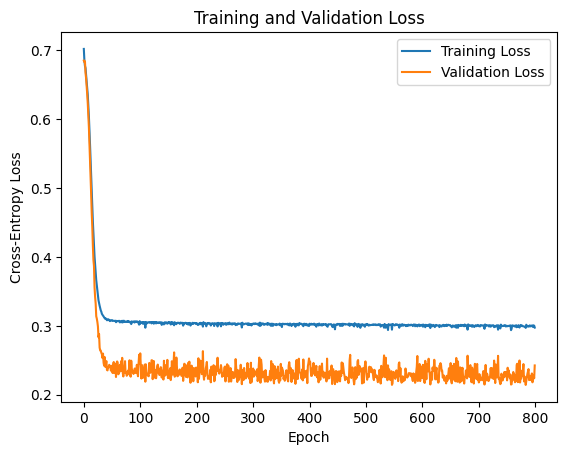

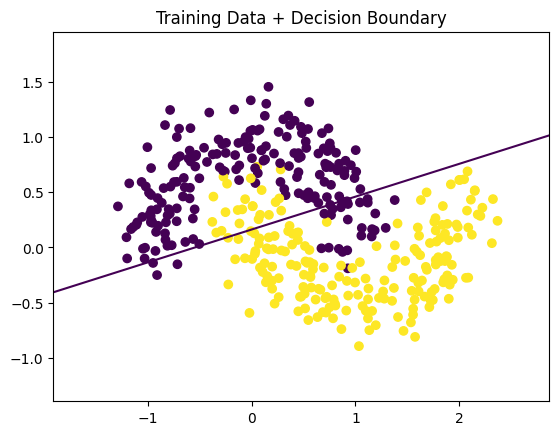

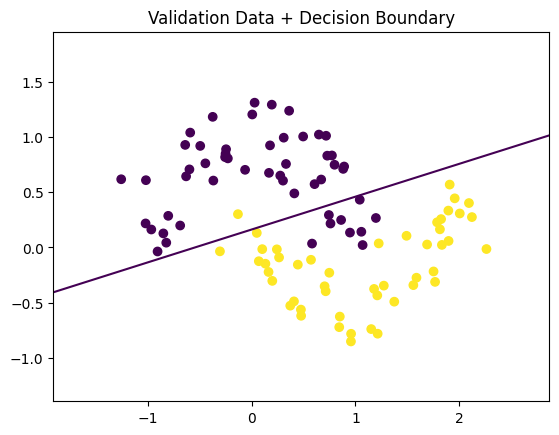

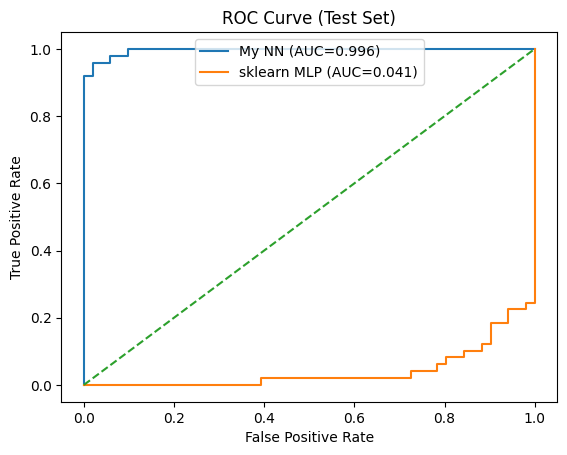

My NN AUC: 0.9959983993597439
sklearn MLP AUC: 0.04081632653061225


In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn.neural_network import MLPClassifier

# create sample data with 500 in training, 100 in test
X_all, y_all = make_moons(n_samples=600, noise=0.20, random_state=0)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_all, y_all, test_size=100, random_state=0
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=0
)


# tune learning rates and epochs
learning_rates = [0.001, 0.01, 0.05, 0.1]
epoch_options = [200, 400, 600, 800, 1000, 1200, 1400, 1600]

best_lr = None
best_epochs = None
best_val_acc = 0

for lr in learning_rates:
    for epochs in epoch_options:
        nn = myNeuralNetwork(2, 5, 5, 1, learning_rate=lr)
        nn.fit(X_train, y_train, max_epochs=epochs)

        preds = nn.predict(X_val).ravel()
        acc = np.mean(preds == y_val)

        if acc > best_val_acc:
            best_val_acc = acc
            best_lr = lr
            best_epochs = epochs

print("Best learning rate:", best_lr)
print("Best epochs:", best_epochs)
print("Best validation accuracy:", best_val_acc)


# loss curves
nn = myNeuralNetwork(2, 5, 5, 1, learning_rate=best_lr)

train_loss, val_loss = nn.fit(
    X_train,
    y_train,
    max_epochs=best_epochs,
    get_validation_loss=True,
    X_val=X_val,
    y_val=y_val,
)

plt.figure()
plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.show()


# plot decision boundaries
def plot_boundary(model, X, y, title):
    x_min, x_max = X_all[:, 0].min() - 0.5, X_all[:, 0].max() + 0.5
    y_min, y_max = X_all[:, 1].min() - 0.5, X_all[:, 1].max() + 0.5

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = model.predict_proba(grid).reshape(xx.shape)

    plt.contour(xx, yy, probs, levels=[0.5])
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.title(title)
    plt.show()


plot_boundary(nn, X_train, y_train, "Training Data + Decision Boundary")
plot_boundary(nn, X_val, y_val, "Validation Data + Decision Boundary")


# retrain on train + validation dataset before evaluating on test and plotting ROC
nn_final = myNeuralNetwork(2, 5, 5, 1, learning_rate=best_lr)
nn_final.fit(X_train_val, y_train_val, max_epochs=best_epochs)

# ROC
y_prob_nn = nn_final.predict_proba(X_test).ravel()
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)
auc_nn = auc(fpr_nn, tpr_nn)


# sklearn comparison, fit a model and evaluate
sk_mlp = MLPClassifier(
    hidden_layer_sizes=(5, 5),
    activation="logistic",
    solver="sgd",
    learning_rate_init=best_lr,
    max_iter=best_epochs,
)

sk_mlp.fit(X_train_val, y_train_val)

y_prob_sk = sk_mlp.predict_proba(X_test)[:, 1]
fpr_sk, tpr_sk, _ = roc_curve(y_test, y_prob_sk)
auc_sk = auc(fpr_sk, tpr_sk)


plt.figure()
plt.plot(fpr_nn, tpr_nn, label=f"My NN (AUC={auc_nn:.3f})")
plt.plot(fpr_sk, tpr_sk, label=f"sklearn MLP (AUC={auc_sk:.3f})")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("ROC Curve (Test Set)")
plt.show()

print("My NN AUC:", auc_nn)
print("sklearn MLP AUC:", auc_sk)

# <div style="page-break-before: always;"></div>
## 2.3 ##

**To improve the neural network, I could add more advanced optimization techniques and better regularization. Instead of the stochasic gradient descent, Adam or momentum-based updates might be better since they converge faster and are less sensitive to the learning rate. I could also use L2 weight decay or droput, which are other regularization methods that could help with overfitting and improve generalization. This can help with stability, convergence speed, and possibly improving test accuracy.**

# <div style="page-break-before: always;"></div>

# <div style="page-break-before: always;"></div>

In [16]:
!pip install -q nbconvert


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [1]:
!jupyter nbconvert --to html hw4.ipynb --TemplateExporter.exclude_input_prompt=True

[NbConvertApp] WARNING | Config option `exclude_output_stderr` not recognized by `HTMLExporter`.  Did you mean one of: `exclude_output, exclude_output_prompt, exclude_output_stdin`?
[NbConvertApp] Converting notebook hw4.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 11 image(s).
[NbConvertApp] Writing 2704452 bytes to hw4.html
